In [1]:
import os, sys
os.environ.setdefault('CONDA_PREFIX', sys.prefix)
os.environ.get('CONDA_PREFIX')

'/opt/conda/envs/python3'

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score

In [3]:
import numpy as np
import pandas as pd

In [4]:
import site
site.addsitedir("../dataprocessing")
from fakenews_functions import change_label

## Preparing data for use in machine learning model

In [5]:
data = pd.read_csv("../data/data_stemmed.csv", index_col=0)
metadata = pd.read_csv("../data/995,000_rows.csv", usecols=["type", "domain"])

In [6]:
data["type"] = metadata["type"].apply(change_label)
data["domain"] = metadata["domain"]

data.dropna(subset=["type"], inplace=True)
data.head()

,content,type,domain
0,plus one articl googl plus ( thank ali alfoneh...,1,nationalreview.com
1,cost best senat bank committe jp morgan buy : ...,0,beforeitsnews.com
2,man awoken <num> -year coma commit suicid lear...,0,dailycurrant.com
3,julia geist ask draw pictur comput scientist l...,1,nytimes.com
4,– <num> compil studi vaccin danger ( activist ...,0,infiniteunknown.net


In [7]:
# Shuffles data and splits it
data = data.sample(frac=1, random_state=0)

split_index1 = int(len(data)*0.8)
split_index2 = int(len(data)*0.9)

data_training = data[:split_index1]
data_validation = data[split_index1:split_index2]
data_testing = data[split_index2:]

In [8]:
vocab_list = pd.read_csv("../data/topwords10000.csv", index_col=0)
vocab_words = vocab_list.index.to_numpy()

In [9]:
vectorizer = CountVectorizer(vocabulary=vocab_words)

In [10]:
X_train = vectorizer.transform(data_training["content"])
y_train = data_training["type"].astype(np.int64)

X_val = vectorizer.transform(data_validation["content"])
y_val = data_validation["type"].astype(np.int64)

X_test = vectorizer.transform(data_testing["content"])
y_test = data_testing["type"].astype(np.int64)

## Logistic regression model

In [11]:
model = LogisticRegression(max_iter=2500)

In [12]:
%%time
model.fit(X_train, y_train)

CPU times: user 11min 46s, sys: 430 ms, total: 11min 46s
Wall time: 1min 57s


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Model testing

In [13]:
pred_y = model.predict(X_test)

In [14]:
f1_score(y_test, pred_y, pos_label=1)

0.8507511430437622

## Logistic regression model with metadata

In [15]:
data["content_domain"] = data["content"] + " " + data["domain"]

In [16]:
data_training2 = data[:split_index1]
data_validation2 = data[split_index1:split_index2]
data_testing2 = data[split_index2:]

In [17]:
X_train2 = vectorizer.transform(data_training2["content_domain"])
y_train2 = data_training2["type"].astype(np.int64)

X_val2 = vectorizer.transform(data_validation2["content_domain"])
y_val2 = data_validation2["type"].astype(np.int64)

X_test2 = vectorizer.transform(data_testing2["content_domain"])
y_test2 = data_testing2["type"].astype(np.int64)

In [18]:
model2 = LogisticRegression(random_state=0,max_iter=2500)

In [20]:
%%time
model2.fit(X_train2, y_train2)

CPU times: user 10min 17s, sys: 557 ms, total: 10min 17s
Wall time: 1min 50s


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

### Testing model with metadata

In [21]:
pred_y_model2 = model2.predict(X_test2)

In [22]:
f1_score(y_test2, pred_y_model2, pos_label=1)

0.8666628551826654

## Confusion matrices

In [23]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

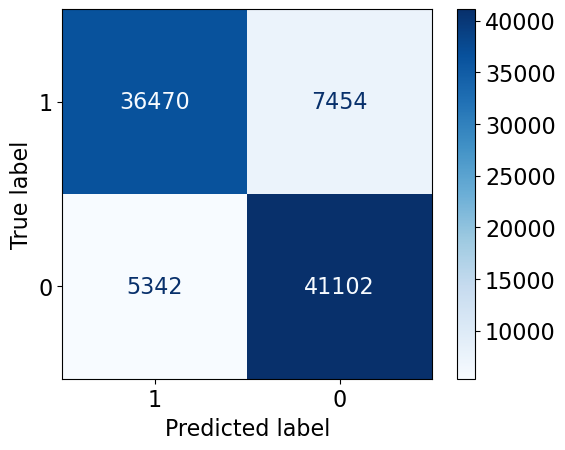

In [24]:
# Model without metadata
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    pred_y, 
    labels=[1, 0],
    display_labels=[1, 0],
    cmap="Blues",
    ax=ax
)

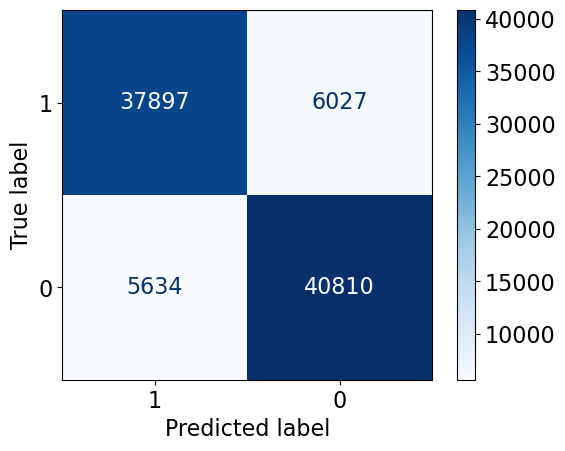

In [25]:
# Model with metadata
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y_test2, 
    pred_y_model2, 
    labels=[1, 0],
    display_labels=[1, 0],
    cmap="Blues",
    ax=ax
)

## Saving models

In [26]:
import joblib

In [27]:
joblib.dump(model,"../models/logistic_model.joblib")

['../models/logistic_model.joblib']

In [28]:
joblib.dump(model2,"../models/logistic_metadata_model.joblib")

['../models/logistic_metadata_model.joblib']